# Embedded Edge-aware Scheduler for real-time Applications in Mobile Edge Computing Scenarios

# Data Analytics & Plots



Make sure you fulfill the following requirements before running this notebook

1) You have both `dataRaw.log` and `ScenarioTimes.log` documents properly created and located in `LOGS` folder *Example:* dataRaw_03-10-2022-10_52_07.log and ScenarioTimes_03-10-2022-10_52_07.log. Make sure both have the exact same date (in our example *03-10-2022-10_52_07*)
2) You have the file `data_transformer.py` together with this notebook in `Data` folder
3) You have all the libraries listed below
4) You have changed the name of the file you want to analyze in cell #2. The ScenarioTimes.log file will be loaded automatically, so you don´t need to set it.

In [2111]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from data_transformer import DataTransformer

In [2112]:
file_name="dataRaw_21-02-2023-18_08_47"
log_file_name=file_name+".log"

First, we need to create the `.json` and `.csv` files from the `.log` files created after running the scenario. Only the `.csv` file will be used in this notebook.

In [2113]:
obj=DataTransformer(log_file_name)
#obj.convertToJSON() #case you only want to create the .json file
#obj.convertToCSV()  #case you only want to create the .csv file
obj.convertToBOTH()  #prefered option is to create both

ScenarioTimes_21-02-2023-18_08_47.log
c:\Users\SISTEMAS\Documents\GitHub\Embeded-edge-aware-scheduler\Algorithm_tests\\LOGS\dataRaw_21-02-2023-18_08_47.log
c:\Users\SISTEMAS\Documents\GitHub\Embeded-edge-aware-scheduler\Algorithm_tests\\LOGS\ScenarioTimes_21-02-2023-18_08_47.log
******START TIME******* 2023-02-21 18:08:58.570909
*******END TIME******* 2023-02-21 18:18:58.570909
delete item AFTER END
{'time': '2023-02-21 18:18:58,600', 'data': {'task_info': {'t1': {'id': 't1', 'OE2EL': 782, 'state': 'READY', 'priority': '2', 'app_type': 'native', 'MAE2EL': 300, 'resources_client': 10, 'resources_server': 10, 'QR': 0, 'pes': 'pes_edge', 'issue': 'issue_not_meeting_deadline'}, 't2': {'id': 't2', 'OE2EL': 50, 'state': 'READY', 'priority': '1', 'app_type': 'local', 'MAE2EL': 500, 'resources_client': 10, 'resources_server': 0, 'QR': 5, 'pes': 'pes_local', 'issue': 'None'}, 't3': {'id': 't3', 'OE2EL': 80, 'state': 'READY', 'priority': '1', 'app_type': 'local', 'MAE2EL': 1000, 'resources_clien

In [2114]:
data_file_name=file_name+".csv" #set the file name to start with the analysis

The function converts data read from the .log file from string to datetime type

In [2115]:

def convertoToDate(date_str):
    date_str_original=date_str
    # year=int(date_str[:date_str.find("-")])
    # date_str=date_str[date_str.find("-")+1:]
    # month=int(date_str[:date_str.find("-")])
    # date_str=date_str[date_str.find("-")+1:]
    # day=int(date_str[:date_str.find(" ")])
    # date_str=date_str[date_str.find(" ")+1:]
    # hour=int(date_str[:date_str.find(":")])
    # date_str=date_str[date_str.find(":")+1:]
    # minute=int(date_str[:date_str.find(":")])
    # date_str=date_str[date_str.find(":")+1:]
    # second=int(date_str[:date_str.find(",")])
    # date_str=date_str[date_str.find(",")+1:]
    # milisec=int(date_str)
    date_time = datetime.strptime(date_str_original, '%Y-%m-%d %H:%M:%S,%f')
    return date_time

function to get the total scenario time from the pandas dataframe

In [2116]:
def getTotalScenarioTime(df):
    scenario_time=convertoToDate(df[df.shape[0]-1]) - convertoToDate(df[0])
    return scenario_time

In [2117]:
def filterActivePart(df):
    active_options = ['ACTIVE'] 
    rslt_df = df[df['t1_state'].isin(active_options)]       
    print('\nResult dataframe :\n',rslt_df)
    return rslt_df

In [2118]:
def filterInactivePart(df):
    inactive_options = ['TIMEOUT', 'SUSPENDED']
    rslt_df = df[df['t1_state'].isin(inactive_options)]       
    print('\nResult dataframe :\n',rslt_df)
    return rslt_df

Import data and create dataframe

In [2119]:
columns = ["time", "t1_state","t2_state","t3_state","t1_OE2EL","t2_OE2EL","t3_OE2EL", "t1_QR", "t2_QR", "t3_QR"]

dirname, filename = os.path.split(os.path.abspath(''))


data_file= dirname+ "\\Data\\Files\\"  +data_file_name



df = pd.read_csv(data_file, usecols=columns)

In [2120]:
print("csv file shape:\n", df.shape)

csv file shape:
 (2670, 10)


In [2121]:
getTotalScenarioTime(df.time)

datetime.timedelta(seconds=600)

Convert df.time column into time format

In [2122]:
for i in range (0,df.shape[0]):
    df.time[i]=convertoToDate(df.time[i])

<ipython-input-2122-f6383c4f161b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.time[i]=convertoToDate(df.time[i])


print dataframe

In [2123]:
#print('\nResult dataframe :\n', df)

# TASK STATES PLOTS


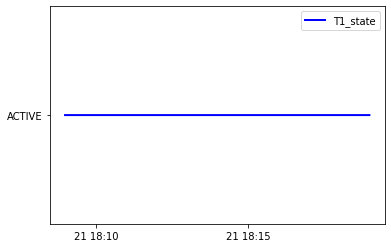

In [2124]:
plt.plot(df.time, df.t1_state,linewidth=2, label='T1_state',color="blue")
plt.legend()
plt.show()

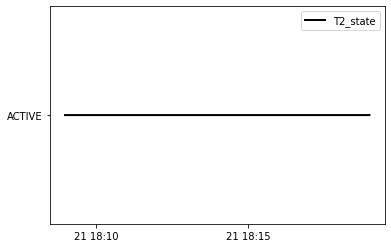

In [2125]:
plt.plot(df.time, df.t2_state,linewidth=2, label='T2_state', color="black")
plt.legend()
plt.show()

<ipython-input-2126-b1325ad98431>:2: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  axes = plt.axes()


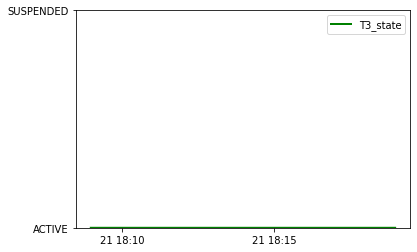

In [2126]:
plt.plot(df.time, df.t3_state,linewidth=2, label='T3_state', color="green")
axes = plt.axes()
axes.set_ylim(["ACTIVE", "SUSPENDED"])
plt.legend()
plt.show()

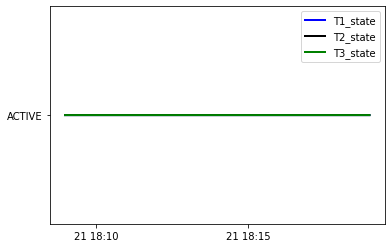

In [2127]:
plt.plot(df.time, df.t1_state,linewidth=2, label='T1_state',color="blue")
plt.plot(df.time, df.t2_state,linewidth=2, label='T2_state', color="black")
plt.plot(df.time, df.t3_state,linewidth=2, label='T3_state', color="green")
plt.legend()
plt.show()

## TASK STATE VS OE2EL

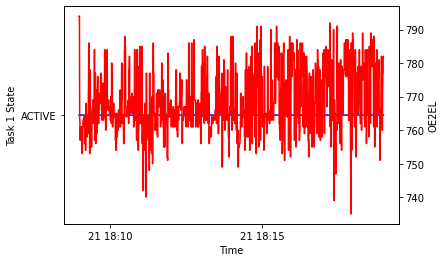

In [2128]:

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(df.time, df.t1_state, 'b-')
ax2.plot(df.time, df.t1_OE2EL, 'r-')

ax1.set_xlabel('Time')
ax1.set_ylabel('Task 1 State')
ax2.set_ylabel('OE2EL')

plt.show()

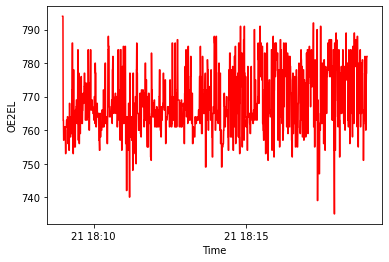

In [2129]:
fig, ax1 = plt.subplots()

ax1.plot(df.time, df.t1_OE2EL, 'r-')

ax1.set_xlabel('Time')
ax1.set_ylabel('OE2EL')

plt.show()

In [2130]:
def drawCDF(data, bins_x=10):
    count, bins_count = np.histogram(data, bins=bins_x)
    
    # finding the PDF of the histogram using count values
    pdf = count / sum(count)
    
    # using numpy np.cumsum to calculate the CDF
    # We can also find using the PDF values by looping and adding
    cdf = np.cumsum(pdf)
    
    # plotting PDF and CDF
    plt.plot(bins_count[1:], pdf, color="red", label="PDF")
    plt.plot(bins_count[1:], cdf, label="CDF")
    plt.legend()

In [2131]:
def drawboxplot(data):
    fig = plt.figure(figsize =(10, 7))
    
    # Creating plot
    plt.boxplot(data)
    
    # show plot
    plt.show()


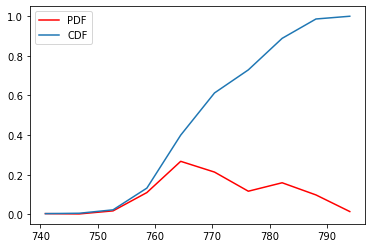

In [2132]:
drawCDF(df.t1_OE2EL, bins_x=10)

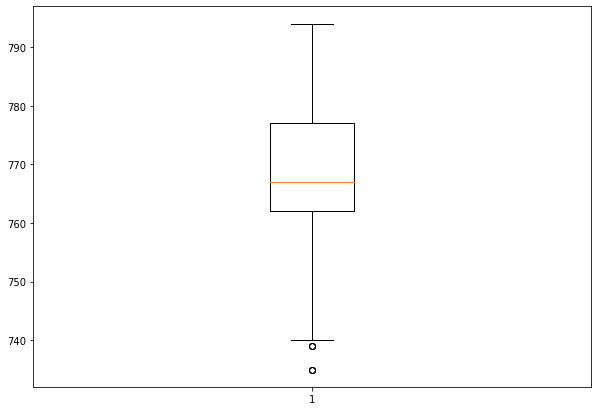

In [2133]:
drawboxplot(df.t1_OE2EL)

In [2134]:
f = open(file_name+"oe2el.txt", "w")
dfAsString = df.t1_OE2EL.to_string(header=False, index=False)
f.write(dfAsString)
f.close()

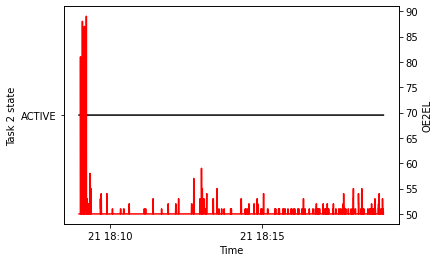

In [2135]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(df.time, df.t2_state, 'black')
ax2.plot(df.time, df.t2_OE2EL, 'r-')

ax1.set_xlabel('Time')
ax1.set_ylabel('Task 2 state')
ax2.set_ylabel('OE2EL')

plt.show()

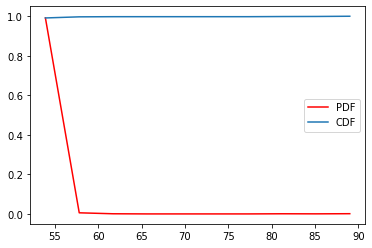

In [2136]:
drawCDF(df.t2_OE2EL, bins_x=10)

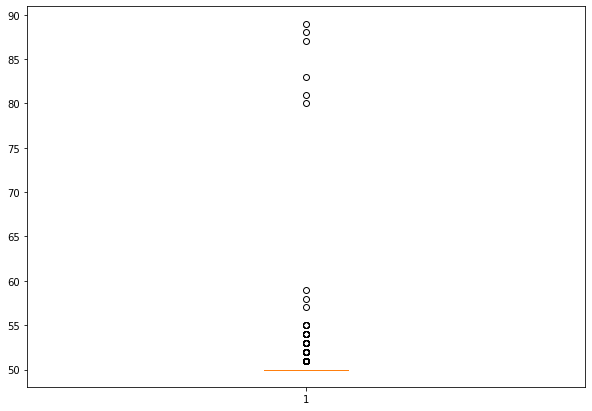

In [2137]:
drawboxplot(df.t2_OE2EL)

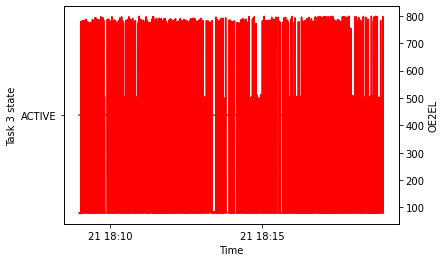

In [2138]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(df.time, df.t3_state, 'green')
ax2.plot(df.time, df.t3_OE2EL, 'r-')

ax1.set_xlabel('Time')
ax1.set_ylabel('Task 3 state')
ax2.set_ylabel('OE2EL')

plt.show()

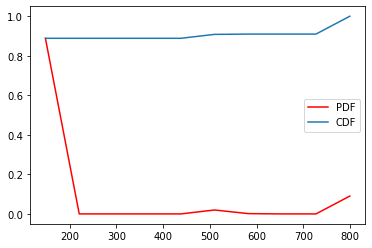

In [2139]:
drawCDF(df.t3_OE2EL, bins_x=10)

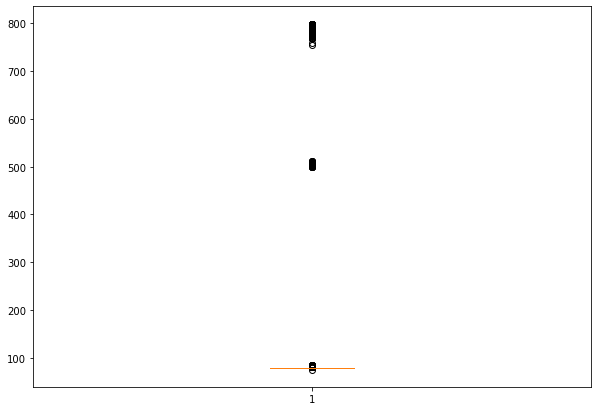

In [2140]:
drawboxplot(df.t3_OE2EL)

## TASK OE2EL VS QUALITY RATE

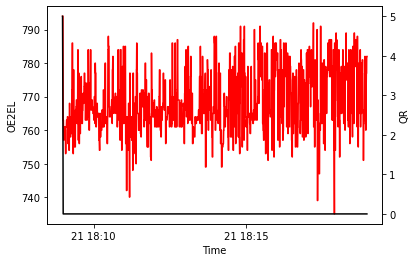

In [2141]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(df.time, df.t1_OE2EL, 'r-', label="OE2EL")
ax2.plot(df.time, df.t1_QR, 'black',label="Quality Rate")

ax1.set_xlabel('Time')
ax1.set_ylabel('OE2EL')
ax2.set_ylabel('QR')
#plt.legend()
plt.show()

# TASK UTILIZATION ANALYSIS

## TASK 1 UTILIZATION ANALYSIS


In [2142]:
df2 = {'time': df.time[len(df)-1], 't1_state': 'END','t2_state': 'END','t3_state': 'END'}

df = df.append(df2, ignore_index = True)

print(type(df2["time"]))

<class 'datetime.datetime'>


In [2143]:
current_state="NULL"
previous_state="NULL"
counter=0
active_list_t1=[]
timeout_list_t1=[]
suspended_list_t1=[]




# iterate trhough the dataframe in order to detect state changes
for  task_state in df.t1_state:
    #first iteration, we need to know the state of the task in order to set the 'state'_start_time
    if counter==0:
        if (task_state=="ACTIVE"):
            active_start_time=df.time[0]
        elif (task_state=="TIMEOUT"):
            timeout_start_time=df.time[0]
        elif (task_state=="SUSPENDED"):
            suspended_start_time=df.time[0]
        else:
            pass     

    current_state=task_state
    #case the previous registered state is different than current state, there is a change in the task state
    if (current_state!=previous_state):
        #print("state change in:")
        #print(df.time[counter])
        
        if (previous_state=="ACTIVE"):
            active_end_time=df.time[counter]
            #print("NEW ACTIVE END TIME: ",active_end_time)
            active_list_t1.append([active_start_time,active_end_time])
        elif (previous_state=="TIMEOUT"):
            timeout_end_time=df.time[counter]
            #print("NEW TIMEOUT END TIME: ",timeout_end_time)
            timeout_list_t1.append([timeout_start_time,timeout_end_time])         
        elif (previous_state=="SUSPENDED"):
            suspended_end_time=df.time[counter]
            #print("NEW SUSPENDED END TIME: ",suspended_end_time)
            suspended_list_t1.append([suspended_start_time,suspended_end_time])
        else:
            pass

        if (current_state=="ACTIVE"):
            active_start_time=df.time[counter]
            #print("NEW ACTIVE START TIME: ",active_start_time)
        elif (current_state=="TIMEOUT"):
            timeout_start_time=df.time[counter]
            #print("NEW TIMEOUT START TIME: ",timeout_start_time)
        elif (current_state=="SUSPENDED"):
            suspended_start_time=df.time[counter]
            #print("NEW SUSPENDED START TIME: ",suspended_start_time)
        else:
            pass


    counter=counter+1
    previous_state=current_state 

print("****************************")
print("active_list")
print(active_list_t1)
print("****************************")
print("timeout_list")
print(timeout_list_t1)

print("****************************")
print("suspended_list")
print(suspended_list_t1)



****************************
active_list
[[datetime.datetime(2023, 2, 21, 18, 8, 58, 570909), Timestamp('2023-02-21 18:18:58.570909')]]
****************************
timeout_list
[]
****************************
suspended_list
[]


### TASK1 ACTIVE TIME CALCULATION

In [2144]:
active_time_task1=datetime(2022, 1, 1)
print(active_time_task1)
for element in active_list_t1:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    active_time_task1=active_time_task1+dif

print("ACTIVE TIME: ",active_time_task1 )
minutes_time= (int(active_time_task1.minute))
seconds_time= (int(active_time_task1.second))
microseconds_time= (int(active_time_task1.microsecond))

active_time_task1_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("ACTIVE TIME: ",active_time_task1_int )


2022-01-01 00:00:00
dif:  0 days 00:10:00
ACTIVE TIME:  2022-01-01 00:10:00
ACTIVE TIME:  600.0


### TASK1 SUSPENDED TIME CALCULATION

In [2145]:
suspended_time_task1=datetime(2022, 1, 1)
print(suspended_time_task1)
for element in suspended_list_t1:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    suspended_time_task1=suspended_time_task1+dif

print("SUSPENDED TIME: ",suspended_time_task1 )
minutes_time= (int(suspended_time_task1.minute))
seconds_time= (int(suspended_time_task1.second))
microseconds_time= (int(suspended_time_task1.microsecond))

suspended_time_task1_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("SUSPENDED TIME: ",suspended_time_task1_int )


2022-01-01 00:00:00
SUSPENDED TIME:  2022-01-01 00:00:00
SUSPENDED TIME:  0.0


### TASK1 TIMEOUT TIME CALCULATION

In [2146]:
timeout_time_task1=datetime(2022, 1, 1)
print(timeout_time_task1)
for element in timeout_list_t1:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    timeout_time_task1=timeout_time_task1+dif

print("TIMEOUT TIME: ",timeout_time_task1 )
minutes_time= (int(timeout_time_task1.minute))
seconds_time= (int(timeout_time_task1.second))
microseconds_time= (int(timeout_time_task1.microsecond))

timeout_time_task1_int=(minutes_time)+seconds_time+microseconds_time/1000000
print("TIMEOUT TIME: ",timeout_time_task1_int )

2022-01-01 00:00:00
TIMEOUT TIME:  2022-01-01 00:00:00
TIMEOUT TIME:  0.0


### TASK1 INACTIVE TIME CALCULATION

In [2147]:
inactive_time_task1_int=timeout_time_task1_int+suspended_time_task1_int


### TASK1 UTILIZATION SUMMARY

In [2148]:
scenario_time= df.time[len(df)-1] - df.time[0]
scenario_time_int=int(scenario_time.seconds)
print("SCENARIO TIME: ", scenario_time_int)
print("ACTIVE TIME: ",active_time_task1_int )
print("INACTIVE TIME: ", inactive_time_task1_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task1_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task1_int)/ scenario_time_int)

SCENARIO TIME:  600
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0


## TASK 2 UTILIZATION ANALYSIS

In [2149]:
current_state="NULL"
previous_state="NULL"
counter=0
active_list_t2=[]
timeout_list_t2=[]
suspended_list_t2=[]


for  task_state in df.t2_state:

    if counter==0:
        if (task_state=="ACTIVE"):
            active_start_time=df.time[0]
        elif (task_state=="TIMEOUT"):
            timeout_start_time=df.time[0]
        elif (task_state=="SUSPENDED"):
            suspended_start_time=df.time[0]
        else:
            pass     

    current_state=task_state
    if (current_state!=previous_state):
        print("state change in:")
        print(df.time[counter])
        
        if (previous_state=="ACTIVE"):
            active_end_time=df.time[counter]
            #print("NEW ACTIVE END TIME: ",active_end_time)
            active_list_t2.append([active_start_time,active_end_time])
        elif (previous_state=="TIMEOUT"):
            timeout_end_time=df.time[counter]
            #print("NEW TIMEOUT END TIME: ",timeout_end_time)
            timeout_list_t2.append([timeout_start_time,timeout_end_time])         
        elif (previous_state=="SUSPENDED"):
            suspended_end_time=df.time[counter]
            #print("NEW SUSPENDED END TIME: ",suspended_end_time)
            suspended_list_t2.append([suspended_start_time,suspended_end_time])
        else:
            pass

        if (current_state=="ACTIVE"):
            active_start_time=df.time[counter]
            #print("NEW ACTIVE START TIME: ",active_start_time)
        elif (current_state=="TIMEOUT"):
            timeout_start_time=df.time[counter]
            #print("NEW TIMEOUT START TIME: ",timeout_start_time)
        elif (current_state=="SUSPENDED"):
            suspended_start_time=df.time[counter]
            #print("NEW SUSPENDED START TIME: ",suspended_start_time)
        else:
            pass


    counter=counter+1
    previous_state=current_state 

print("****************************")
print("active_list")
print("****************************")
print(active_list_t2)
print("****************************")
print("timeout_list")
print("****************************")
print(timeout_list_t2)

print("****************************")
print("suspended_list")
print("****************************")
print(suspended_list_t2)


state change in:
2023-02-21 18:08:58.570909
state change in:
2023-02-21 18:18:58.570909
****************************
active_list
****************************
[[datetime.datetime(2023, 2, 21, 18, 8, 58, 570909), Timestamp('2023-02-21 18:18:58.570909')]]
****************************
timeout_list
****************************
[]
****************************
suspended_list
****************************
[]


### TASK2 ACTIVE TIME CALCULATION

In [2150]:
active_time_task2=datetime(2022, 1, 1)
print(active_time_task2)
for element in active_list_t2:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    active_time_task2=active_time_task2+dif

print("ACTIVE TIME: ",active_time_task2 )
minutes_time= (int(active_time_task2.minute))
seconds_time= (int(active_time_task2.second))
microseconds_time= (int(active_time_task2.microsecond))

active_time_task2_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("ACTIVE TIME: ",active_time_task2_int )

2022-01-01 00:00:00
dif:  0 days 00:10:00
ACTIVE TIME:  2022-01-01 00:10:00
ACTIVE TIME:  600.0


### TASK2 SUSPENDED TIME CALCULATION

In [2151]:
suspended_time_task2=datetime(2022, 1, 1)
print(suspended_time_task2)
for element in suspended_list_t2:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    suspended_time_task2=suspended_time_task2+dif

print("SUSPENDED TIME: ",suspended_time_task2 )
minutes_time= (int(suspended_time_task2.minute))
seconds_time= (int(suspended_time_task2.second))
microseconds_time= (int(suspended_time_task2.microsecond))

suspended_time_task2_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("SUSPENDED TIME: ",suspended_time_task2_int )

2022-01-01 00:00:00
SUSPENDED TIME:  2022-01-01 00:00:00
SUSPENDED TIME:  0.0


### TASK2 TIMEOUT TIME CALCULATION

In [2152]:
timeout_time_task2=datetime(2022, 1, 1)
print(timeout_time_task2)
for element in timeout_list_t2:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    timeout_time_task2=timeout_time_task2+dif

print("TIMEOUT TIME: ",timeout_time_task2 )
minutes_time= (int(timeout_time_task2.minute))
seconds_time= (int(timeout_time_task2.second))
microseconds_time= (int(timeout_time_task2.microsecond))

timeout_time_task2_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("TIMEOUT TIME: ",timeout_time_task2_int )

2022-01-01 00:00:00
TIMEOUT TIME:  2022-01-01 00:00:00
TIMEOUT TIME:  0.0


### TASK2 INACTIVE TIME CALCULATION

In [2153]:
inactive_time_task2_int=timeout_time_task2_int+suspended_time_task2_int

In [2154]:

print("SCENARIO TIME: ", scenario_time_int)
print("ACTIVE TIME: ",active_time_task2_int )
print("INACTIVE TIME: ", inactive_time_task2_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task2_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task2_int)/ scenario_time_int)

SCENARIO TIME:  600
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0


## TASK3 UTILIZATION ANALYSIS

In [2155]:
current_state="NULL"
previous_state="NULL"
counter=0
active_list_t3=[]
timeout_list_t3=[]
suspended_list_t3=[]


for  task_state in df.t3_state:

    if counter==0:
        if (task_state=="ACTIVE"):
            active_start_time=df.time[0]
        elif (task_state=="TIMEOUT"):
            timeout_start_time=df.time[0]
        elif (task_state=="SUSPENDED"):
            suspended_start_time=df.time[0]
        else:
            pass     

    current_state=task_state
    if (current_state!=previous_state):
        print("state change in:")
        print(df.time[counter])
        
        if (previous_state=="ACTIVE"):
            active_end_time=df.time[counter]
            #print("NEW ACTIVE END TIME: ",active_end_time)
            active_list_t3.append([active_start_time,active_end_time])
        elif (previous_state=="TIMEOUT"):
            timeout_end_time=df.time[counter]
            #print("NEW TIMEOUT END TIME: ",timeout_end_time)
            timeout_list_t3.append([timeout_start_time,timeout_end_time])         
        elif (previous_state=="SUSPENDED"):
            suspended_end_time=df.time[counter]
            #print("NEW SUSPENDED END TIME: ",suspended_end_time)
            suspended_list_t3.append([suspended_start_time,suspended_end_time])
        else:
            pass

        if (current_state=="ACTIVE"):
            active_start_time=df.time[counter]
            #print("NEW ACTIVE START TIME: ",active_start_time)
        elif (current_state=="TIMEOUT"):
            timeout_start_time=df.time[counter]
            #print("NEW TIMEOUT START TIME: ",timeout_start_time)
        elif (current_state=="SUSPENDED"):
            suspended_start_time=df.time[counter]
            #print("NEW SUSPENDED START TIME: ",suspended_start_time)
        else:
            pass


    counter=counter+1
    previous_state=current_state 

print("****************************")
print("active_list")
print("****************************")
print(active_list_t3)
print("****************************")
print("timeout_list")
print("****************************")
print(timeout_list_t3)

print("****************************")
print("suspended_list")
print("****************************")
print(suspended_list_t3)

state change in:
2023-02-21 18:08:58.570909
state change in:
2023-02-21 18:18:58.570909
****************************
active_list
****************************
[[datetime.datetime(2023, 2, 21, 18, 8, 58, 570909), Timestamp('2023-02-21 18:18:58.570909')]]
****************************
timeout_list
****************************
[]
****************************
suspended_list
****************************
[]


### TASK3 ACTIVE TIME CALCULATION

In [2156]:
active_time_task3=datetime(2022, 1, 1)
print(active_time_task3)
for element in active_list_t3:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    active_time_task3=active_time_task3+dif

print("ACTIVE TIME: ",active_time_task3 )
minutes_time= (int(active_time_task3.minute))
seconds_time= (int(active_time_task3.second))
microseconds_time= (int(active_time_task3.microsecond))

active_time_task3_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("ACTIVE TIME: ",active_time_task3_int )

2022-01-01 00:00:00
dif:  0 days 00:10:00
ACTIVE TIME:  2022-01-01 00:10:00
ACTIVE TIME:  600.0


### TASK3 SUSPENDED TIME CALCULATION

In [2157]:
suspended_time_task3=datetime(2022, 1, 1)
print(suspended_time_task3)
for element in suspended_list_t3:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    suspended_time_task3=suspended_time_task3+dif

print("SUSPENDED TIME: ",suspended_time_task3 )
minutes_time= (int(suspended_time_task3.minute))
seconds_time= (int(suspended_time_task3.second))
microseconds_time= (int(suspended_time_task3.microsecond))

suspended_time_task3_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("SUSPENDED TIME: ",suspended_time_task3_int )

2022-01-01 00:00:00
SUSPENDED TIME:  2022-01-01 00:00:00
SUSPENDED TIME:  0.0


### TASK3 TIMEOUT TIME CALCULATION

In [2158]:
timeout_time_task3=datetime(2022, 1, 1)
print(timeout_time_task3)
for element in timeout_list_t3:
    # print(type(element[1]), type(element[0]))
    dif= element[1]-element[0]
    print("dif: ", dif)
    timeout_time_task3=timeout_time_task3+dif

print("TIMEOUT TIME: ",timeout_time_task3 )
minutes_time= (int(timeout_time_task3.minute))
seconds_time= (int(timeout_time_task3.second))
microseconds_time= (int(timeout_time_task3.microsecond))

timeout_time_task3_int=(minutes_time*60)+seconds_time+microseconds_time/1000000
print("TIMEOUT TIME: ",timeout_time_task3_int )

2022-01-01 00:00:00
TIMEOUT TIME:  2022-01-01 00:00:00
TIMEOUT TIME:  0.0


### TASK3 INACTIVE TIME CALCULATION

In [2159]:
inactive_time_task3_int=timeout_time_task3_int+suspended_time_task3_int

In [2160]:

print("SCENARIO TIME: ", scenario_time_int)
print("ACTIVE TIME: ",active_time_task3_int )
print("INACTIVE TIME: ", inactive_time_task3_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task3_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task3_int)/ scenario_time_int)

SCENARIO TIME:  600
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0


## TASK UTILIZATION SUMMARY

In [2161]:

print("SCENARIO FILE: ", file_name)
print("SCENARIO TIME: ", scenario_time_int)
print("*******************  TASK1  *******************")
print("ACTIVE TIME: ",active_time_task1_int )
print("INACTIVE TIME: ", inactive_time_task1_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task1_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task1_int)/ scenario_time_int)
print("*******************  TASK2  *******************")
print("ACTIVE TIME: ",active_time_task2_int )
print("INACTIVE TIME: ", inactive_time_task2_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task2_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task2_int)/ scenario_time_int)
print("*******************  TASK3  *******************")
print("ACTIVE TIME: ",active_time_task3_int )
print("INACTIVE TIME: ", inactive_time_task3_int)
print("UTILIZATION PERCENTAGE: ", (100*active_time_task3_int)/ scenario_time_int)
print("IDLE PERCENTAGE: ", (100*inactive_time_task3_int)/ scenario_time_int)

SCENARIO FILE:  dataRaw_21-02-2023-18_08_47
SCENARIO TIME:  600
*******************  TASK1  *******************
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0
*******************  TASK2  *******************
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0
*******************  TASK3  *******************
ACTIVE TIME:  600.0
INACTIVE TIME:  0.0
UTILIZATION PERCENTAGE:  100.0
IDLE PERCENTAGE:  0.0
